In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.grid"] = True

RESULTS_DIR = "/scratch/elena/WCTE_recovery/results"
YMIN, YMAX = 100, 200

# Listar todos los npz
all_npz = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith(".npz")])
print(f"Found {len(all_npz)} npz files")


def parse_filename(fname):
    """
    Example filenames:
        Final_run2306_770ps_chunk0.npz
        Final_run2055_810ps_chunk3.npz
    Returns: run (int), pulse_width (int), chunk (int)
    """
    m = re.match(r"Final_run(\d+)_(\d+)ps_chunk(\d+)\.npz", fname)
    if m:
        run = int(m.group(1))
        pulse_width = int(m.group(2))
        chunk = int(m.group(3))
        return run, pulse_width, chunk
    else:
        raise ValueError(f"Filename {fname} does not match pattern")

Found 40 npz files


In [ ]:
def load_run_results(run, pulse_width):
    files = [f for f in all_npz if f"run{run}_{pulse_width}ps" in f]
    files = sorted(files, key=lambda x: int(re.search(r"chunk(\d+)", x).group(1)))

    all_chunks = []
    for f in files:
        data = np.load(os.path.join(RESULTS_DIR, f))["results"]
        all_chunks.append(data)

    results = np.concatenate(all_chunks)
    return results


def extract_spe_info(results):
    pmt_labels = []
    x_labels = []
    seen_mpmt = set()

    for r in results:
        key = (r["card_id"], r["slot_id"])
        if key not in seen_mpmt:
            x_labels.append(f"card{r['card_id']}_slot{r['slot_id']}")
            seen_mpmt.add(key)
        else:
            x_labels.append("")

        pmt_labels.append(f"{r['card_id']}_{r['slot_id']}_{r['channel_id']}")

    x = np.arange(len(pmt_labels))

    mu_spe = results["gain"].astype(float)
    err_mu_spe = np.sqrt(
        (results["pedestal_sigma"] / np.sqrt(results["N_pedestal"]))**2 +
        (results["spe_sigma"] / np.sqrt(results["N_spe"]))**2
    )

    mu_spe[~np.isfinite(mu_spe)] = np.nan
    err_mu_spe[~np.isfinite(err_mu_spe)] = np.nan

    return x, x_labels, pmt_labels, mu_spe, err_mu_spe

Found 40 npz files


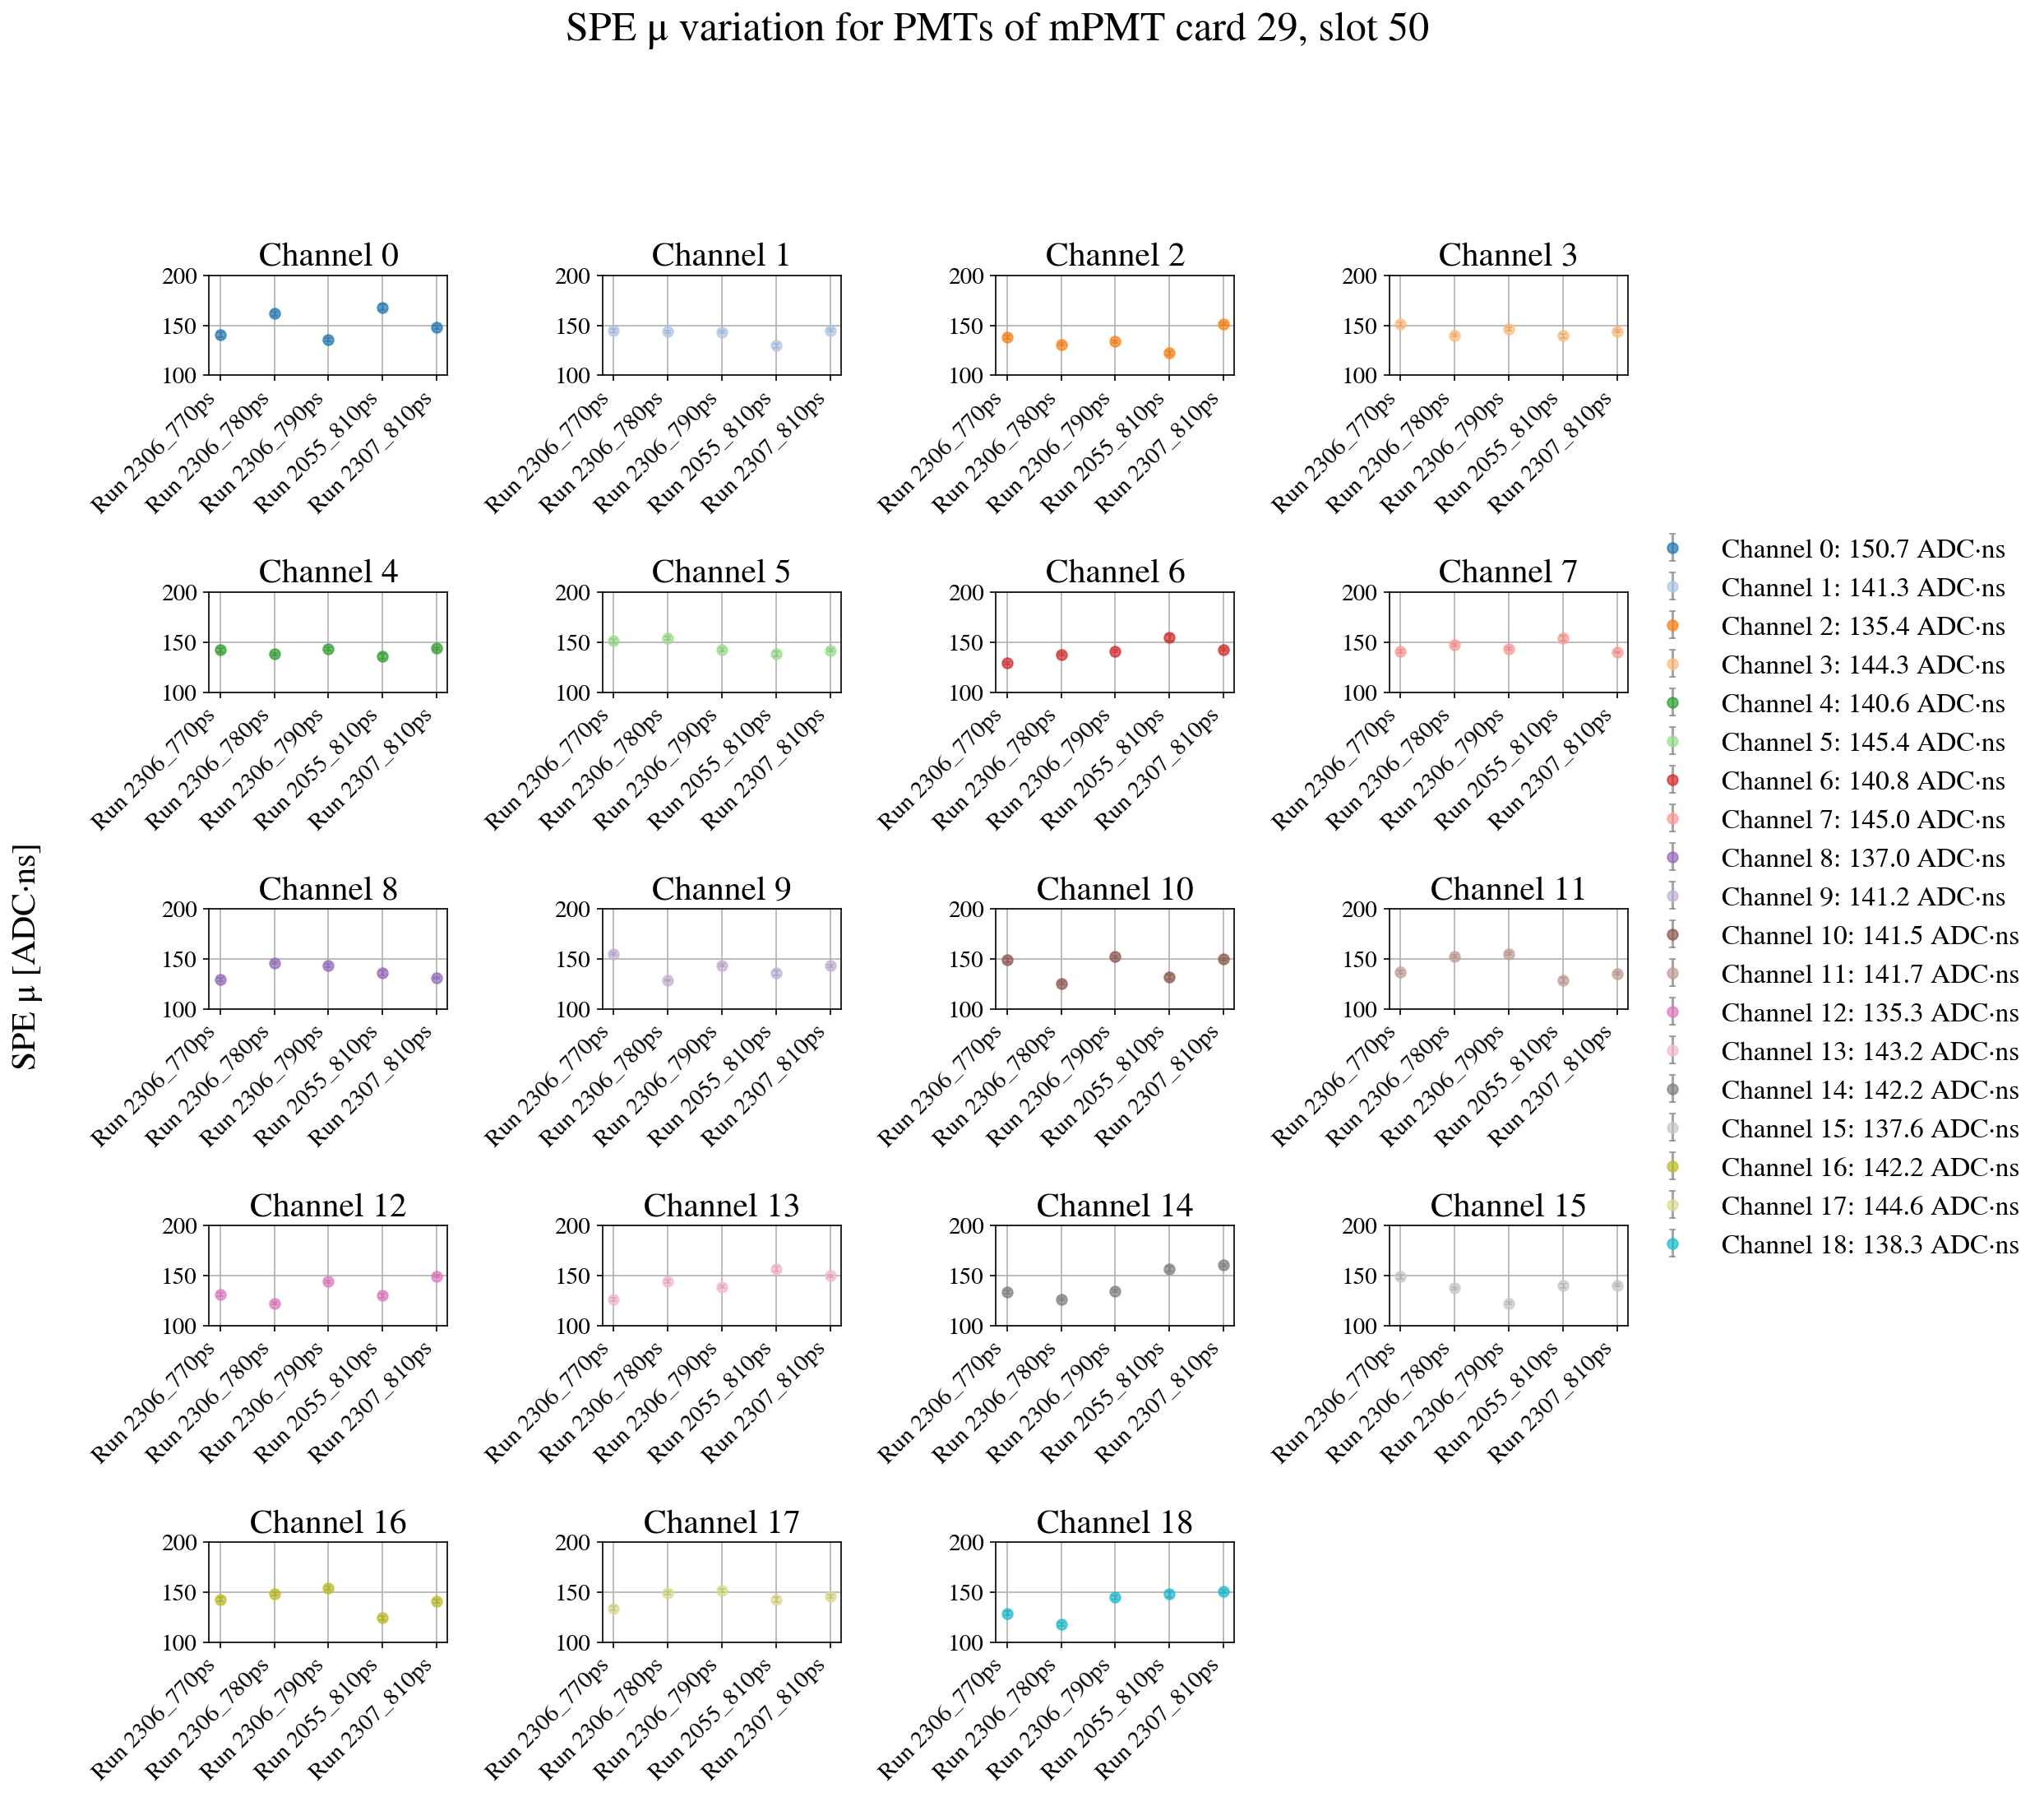

In [36]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# -------------------------------
# Matplotlib formatting
# -------------------------------
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [18, 16]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14

RESULTS_DIR = "/scratch/elena/WCTE_recovery/results"

# -------------------------------
# List all npz files
# -------------------------------
all_npz = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith(".npz")])
print(f"Found {len(all_npz)} npz files")


def parse_filename(fname):
    m = re.match(r"Final_run(\d+)_(\d+)ps_chunk(\d+)\.npz", fname)
    if m:
        run = int(m.group(1))
        pulse_width = int(m.group(2))
        chunk = int(m.group(3))
        return run, pulse_width, chunk
    else:
        raise ValueError(f"Filename {fname} does not match pattern")


def load_run_results(run, pulse_width):
    files = [f for f in all_npz if f"run{run}_{pulse_width}ps" in f]
    files = sorted(files, key=lambda x: int(re.search(r"chunk(\d+)", x).group(1)))
    all_chunks = []
    for f in files:
        data = np.load(os.path.join(RESULTS_DIR, f))["results"]
        all_chunks.append(data)
    results = np.concatenate(all_chunks)
    return results


def extract_spe_info(results, card_id, slot_id):
    """
    Extract SPE mean and error using 'spe_mean' and 'spe_sigma' for each channel.
    """
    mask = (results["card_id"] == card_id) & (results["slot_id"] == slot_id)
    results_mpmt = results[mask]

    spe_dict = {}
    for ch in range(19):
        ch_mask = results_mpmt["channel_id"] == ch
        if np.any(ch_mask):
            mu_spe = results_mpmt['spe_mean'][ch_mask].astype(float)[0]
            sigma_spe = results_mpmt['spe_sigma'][ch_mask].astype(float)[0]
            N_spe = results_mpmt['N_spe'][ch_mask][0]
            # error bar = simple fit error
            err_mu_spe = sigma_spe / np.sqrt(N_spe)

            # sanity check
            if not np.isfinite(mu_spe):
                mu_spe = np.nan
            if not np.isfinite(err_mu_spe):
                err_mu_spe = np.nan

            spe_dict[ch] = (mu_spe, err_mu_spe)
        else:
            spe_dict[ch] = (np.nan, np.nan)
    return spe_dict


# -------------------------------
# Main analysis for one mPMT
# -------------------------------
card_id = 29
slot_id = 50

run_pulse_list = sorted(set((parse_filename(f)[0], parse_filename(f)[1]) for f in all_npz))
channel_results = {ch: {"runs": [], "mu": [], "err": []} for ch in range(19)}

for run, pulse_width in run_pulse_list:
    results = load_run_results(run, pulse_width)
    spe_dict = extract_spe_info(results, card_id, slot_id)
    for ch in range(19):
        mu, err = spe_dict[ch]
        channel_results[ch]["runs"].append(f"{run}_{pulse_width}ps")
        channel_results[ch]["mu"].append(mu)
        channel_results[ch]["err"].append(err)

# -------------------------------
# Plot 19 subplots with compact spacing
# -------------------------------
colors_list = plt.cm.tab20.colors
fig, axes = plt.subplots(5, 4, figsize=(17, 15))
axes = axes.flatten()
legend_labels = []

for ch in range(19):
    ax = axes[ch]

    # Convert to arrays
    mu_spe_all = np.array(channel_results[ch]["mu"])
    err_mu_spe_all = np.array(channel_results[ch]["err"])
    x_labels_all = np.array(channel_results[ch]["runs"])

    # Extract pulse width from labels to sort
    pulse_widths = np.array([int(lbl.split('_')[1].replace('ps','')) for lbl in x_labels_all])
    sort_idx = np.argsort(pulse_widths)  # indices that sort by pulse width

    # Apply sorting
    mu_spe_all = mu_spe_all[sort_idx]
    err_mu_spe_all = err_mu_spe_all[sort_idx]
    x_labels_all = x_labels_all[sort_idx]

    # Add "Run" prefix
    x_labels_all = np.array([f"Run {lbl}" for lbl in x_labels_all])

    # x-axis positions
    x_all = np.arange(len(x_labels_all))

    # plot SPE μ ± error (simple style)
    ax.errorbar(
        x_all, mu_spe_all, yerr=err_mu_spe_all,
        fmt='o', color=colors_list[ch % len(colors_list)],
        alpha=0.7, ecolor='gray', capsize=2
    )
    ax.set_title(f"Channel {ch}")
    ax.set_xticks(x_all)
    ax.set_xticklabels(x_labels_all, rotation=45, ha="right")
    ax.set_ylim(100, 200)
    ax.grid(True)

    mean_spe = np.nanmean(mu_spe_all)
    legend_labels.append(f"Channel {ch}: {mean_spe:.1f} ADC·ns")

axes[-1].axis("off")

fig.text(0.03, 0.5, "SPE μ [ADC·ns]", va='center', rotation='vertical', fontsize=20)
plt.suptitle(f"SPE μ variation for PMTs of mPMT card {card_id}, slot {slot_id}", fontsize=24, y=1.01)
fig.legend(legend_labels, loc='center right', fontsize=16, frameon=False)
plt.tight_layout(rect=[0.05, 0.03, 0.82, 0.95])

save_path = f"/scratch/elena/WCTE_recovery/plots/SPE_mean_variation_mPMT_{card_id,slot_id}.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 

plt.show()